##Install Dependencies

In [ ]:
!pip install -q ragas langchain langchain-openai langchain-huggingface psycopg2-binary pgvector langchain-postgres datasets nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.1/550.1 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 k

##The VertexAI Fix

In [ ]:
import sys
import types

class DummyVertexAI: pass
class DummyChatVertexAI: pass

dummy_llms = types.ModuleType("langchain_community.llms")
dummy_llms.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms"] = dummy_llms

dummy_chat_models = types.ModuleType("langchain_community.chat_models")
dummy_chat_models.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models"] = dummy_chat_models

dummy_chat_vertexai = types.ModuleType("langchain_community.chat_models.vertexai")
dummy_chat_vertexai.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat_vertexai

dummy_llms_vertexai = types.ModuleType("langchain_community.llms.vertexai")
dummy_llms_vertexai.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms.vertexai"] = dummy_llms_vertexai

##Setup, Database & Prompts

In [ ]:
import os
import json
import pandas as pd
import time
import nest_asyncio
from google.colab import userdata, drive
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres import PGVector
from langchain_core.prompts import PromptTemplate

nest_asyncio.apply()
drive.mount('/content/drive')

# 1. SETUP PATHS & CREDENTIALS
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'
df = pd.read_csv(DATASET_PATH)

NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

# 2. INITIALIZE TEST MODEL & DATABASE
print("Connecting to GPT-4o-mini and Original PGVector Database...")
test_llm = ChatOpenAI(model="openai/gpt-4o-mini", api_key=os.environ["OPENROUTER_API_KEY"], base_url="https://openrouter.ai/api/v1", temperature=0)

bge_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={'device': 'cpu'})

vector_store = PGVector(
    embeddings=bge_embeddings,
    collection_name="awmf_baseline_bge", # Using original DB for fair A/B test
    connection=NEON_CONNECTION_STRING,
    use_jsonb=True
)
retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# 3. THE NEW EXPANSION PROMPT
translation_expansion_prompt = PromptTemplate(
    template="""You are an expert medical search term generator.
First, translate the following English medical question into German.
Then, generate 3 to 4 highly formal German clinical synonyms, related medical conditions, or official MeSH terms (Query Expansion) that would likely appear in a formal clinical guideline.
Output ONLY the translated question and the synonyms combined as a single continuous search string. Do not include bullet points, labels, or introductory text.

English Question:
{question}""",
    input_variables=["question"]
)

qa_prompt = PromptTemplate(
    template="You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.\nUse ONLY the provided German context to formulate your answer.\n\nContext (German):\n{context}\n\nQuestion (English):\n{question}\n\nAnswer (English):",
    input_variables=["context", "question"]
)
print("Setup complete! Ready to generate.")

Mounted at /content/drive
Connecting to GPT-4o-mini and Original PGVector Database...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Setup complete! Ready to generate.


##The Generation Loop

In [ ]:
llm_roster = [
    {"name": "gpt-4o-mini", "model_string": "openai/gpt-4o-mini"},
    {"name": "mistral-large", "model_string": "mistralai/mistral-large"},
    {"name": "gemini-2.5-flash", "model_string": "google/gemini-2.5-flash"},
    {"name": "claude-sonnet-4.6", "model_string": "anthropic/claude-sonnet-4.6"},
    {"name": "llama-3.1-70b", "model_string": "meta-llama/llama-3.1-70b-instruct"},
    {"name": "deepseek-chat", "model_string": "deepseek/deepseek-chat"}
]

print("STARTING MULTI-MODEL QUERY EXPANSION TEST...")

for competitor in llm_roster:
    model_name = competitor["name"]
    model_string = competitor["model_string"]
    output_file = f"{DRIVE_PATH}EXPANSION_TEST_{model_name}_results.json"

    print(f"\n" + "="*50)
    print(f"NOW EXPANDING QUERIES WITH: {model_name.upper()}")
    print("="*50)

    current_llm = ChatOpenAI(
        model=model_string,
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )

    results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    for index, row in df.iterrows():
        english_question = row['English_Open_Question']
        english_ground_truth = row['English_Correct_Text']

        try:
            # 1. TRANSLATE AND EXPAND
            formatted_trans_prompt = translation_expansion_prompt.format(question=english_question)
            expanded_german_query = current_llm.invoke(formatted_trans_prompt).content.strip()

            # 2. RETRIEVE
            retrieved_docs = retriever.invoke(expanded_german_query)
            contexts = [doc.page_content for doc in retrieved_docs]
            context_string = "\n\n".join(contexts)

            # 3. GENERATE ANSWER
            formatted_qa_prompt = qa_prompt.format(context=context_string, question=english_question)
            response_msg = current_llm.invoke(formatted_qa_prompt)

            # 4. SAVE
            results["question"].append(english_question)
            results["answer"].append(response_msg.content)
            results["contexts"].append(contexts)
            results["ground_truth"].append(english_ground_truth)

            with open(output_file, 'w') as f:
                json.dump(results, f)

            if (index + 1) % 20 == 0:
                print(f"[{model_name}] Progress: {index + 1}/{len(df)}")
                print(f"Sample Expansion used: {expanded_german_query}\n")

            time.sleep(2) # Protect API limits

        except Exception as e:
            print(f"Error at index {index} for {model_name}: {e}")
            time.sleep(5)
            continue

print("Generation Complete for all 3 models!")

STARTING MULTI-MODEL QUERY EXPANSION TEST...

NOW EXPANDING QUERIES WITH: GPT-4O-MINI
[gpt-4o-mini] Progress: 20/200
Sample Expansion used: Ein 48-jähriger Mann wird in die Notaufnahme gebracht wegen plötzlicher Atemnot vor 6 Stunden. In den letzten Monaten hatte er Atemnot bei Anstrengung und im Liegen, häufige Kopfschmerzen und Schwellungen seiner Füße. Er nimmt keine Medikamente ein, obwohl er vor 10 Jahren mit Bluthochdruck diagnostiziert wurde. Sein Puls beträgt 90/min, die Atmung 20/min, der Blutdruck 150/110 mm Hg und die Temperatur 37,0°C. Die körperliche Untersuchung zeigt einen übergewichtigen Mann in akuter Not mit hörbaren Giemen. Rasselgeräusche sind beidseitig zu hören und am lautesten an den Lungenspitzen. Welches Ergebnis bei der Herzuntersuchung wird bei diesem Patienten am wahrscheinlichsten vorhanden sein? Herzinsuffizienz, Lungenödem, pulmonale Hypertonie, hypertensive Herzkrankheit.

[gpt-4o-mini] Progress: 40/200
Sample Expansion used: Ein 59-jähriger Mann wird we

In [ ]:
import json
import os
import time

model_name = "deepseek-chat"
model_string = "deepseek/deepseek-chat"
output_file = f"{DRIVE_PATH}EXPANSION_TEST_{model_name}_results.json"

print(f"\n" + "="*50)
print(f"RESUMING QUERIES FOR: {model_name.upper()}")
print("="*50)

current_llm = ChatOpenAI(
    model=model_string,
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

# Load the partially saved results to find where we left off
if os.path.exists(output_file):
    with open(output_file, 'r') as f:
        results = json.load(f)
    start_index = len(results["question"])
    print(f"Found existing file. Resuming from index {start_index} out of {len(df)}")
else:
    results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
    start_index = 0
    print("No existing file found. Starting from index 0.")

# Resume the loop from the start_index
for index, row in df.iloc[start_index:].iterrows():
    english_question = row['English_Open_Question']
    english_ground_truth = row['English_Correct_Text']

    try:
        # 1. TRANSLATE AND EXPAND
        formatted_trans_prompt = translation_expansion_prompt.format(question=english_question)
        expanded_german_query = current_llm.invoke(formatted_trans_prompt).content.strip()

        # 2. RETRIEVE
        retrieved_docs = retriever.invoke(expanded_german_query)
        contexts = [doc.page_content for doc in retrieved_docs]
        context_string = "\n\n".join(contexts)

        # 3. GENERATE ANSWER
        formatted_qa_prompt = qa_prompt.format(context=context_string, question=english_question)
        response_msg = current_llm.invoke(formatted_qa_prompt)

        # 4. SAVE
        results["question"].append(english_question)
        results["answer"].append(response_msg.content)
        results["contexts"].append(contexts)
        results["ground_truth"].append(english_ground_truth)

        with open(output_file, 'w') as f:
            json.dump(results, f)

        if (index + 1) % 20 == 0:
            print(f"[{model_name}] Progress: {index + 1}/{len(df)}")
            print(f"Sample Expansion used: {expanded_german_query}\n")

        time.sleep(2) # Protect API limits

    except Exception as e:
        print(f"Error at index {index} for {model_name}: {e}")
        time.sleep(5)
        continue

print(f"Generation Complete for {model_name}!")


RESUMING QUERIES FOR: DEEPSEEK-CHAT
Found existing file. Resuming from index 126 out of 200
[deepseek-chat] Progress: 140/200
Sample Expansion used: Ein 55-jähriger Mann stellt sich mit blutigem Nasensekret und Atemnot vor. Er berichtet, dass er in den letzten zwei Monaten 4 kg (8,8 Pfund) verloren hat, ohne seine Ernährung umgestellt zu haben. Außerdem leidet er seit einem Jahr unter leichten bis mittelstarken Gelenkschmerzen im linken Knie. Seine Vorgeschichte ist unauffällig. Seine Vitalzeichen sind: Blutdruck 120/70 mm Hg, Temperatur 37,0 °C (98,6 °F), Puls 70/min, Atemfrequenz 14/min. Die körperliche Untersuchung zeigt Nasenulzera. Diffuse Rasselgeräusche sind über allen Lungenlappen beidseits vorhanden. Die Laborbefunde sind wie folgt auffällig: Hämoglobin 12,9 g/dL, Hämatokrit 37,7%, Leukozytenzahl 5500/mm3, Neutrophile 65%, Lymphozyten 30%, Monozyten 5%, mittleres korpuskuläres Volumen 82,2 μm3, Thrombozytenzahl 190.000/mm3, Blutsenkungsgeschwindigkeit 35 mm/h, C-reaktives Pro

##Ragas Evaluation

In [ ]:
llm_roster = [
    {"name": "gpt-4o-mini", "model_string": "openai/gpt-4o-mini"},
    {"name": "mistral-large", "model_string": "mistralai/mistral-large"},
    {"name": "gemini-2.5-flash", "model_string": "google/gemini-2.5-flash"},
    {"name": "claude-sonnet-4.6", "model_string": "anthropic/claude-sonnet-4.6"},
    {"name": "llama-3.1-70b", "model_string": "meta-llama/llama-3.1-70b-instruct"},
    {"name": "deepseek-chat", "model_string": "deepseek/deepseek-chat"}
]
print("llm_roster redefined!")

llm_roster redefined!


In [ ]:
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

# We use GPT-4o-mini strictly as the Judge
judge_llm = LangchainLLMWrapper(
    ChatOpenAI(model="openai/gpt-4o-mini", api_key=os.environ["OPENROUTER_API_KEY"], base_url="https://openrouter.ai/api/v1", temperature=0)
)
ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)

evaluation_features = Features({
    "question": Value("string"),
    "answer": Value("string"),
    "contexts": Sequence(Value("string")),
    "ground_truth": Value("string"),
})

all_results = []

for competitor in llm_roster:
    model_name = competitor["name"]
    input_file = f"{DRIVE_PATH}EXPANSION_TEST_{model_name}_results.json"

    print(f"\n" + "="*50)
    print(f"GRADING EXPANSION FOR: {model_name.upper()}")

    if not os.path.exists(input_file):
        print(f"File not found: {input_file}. Skipping.")
        continue

    with open(input_file, 'r') as f:
        data = json.load(f)

    eval_dataset = Dataset.from_dict(data, features=evaluation_features)

    try:
        eval_results = evaluate(
            dataset=eval_dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=judge_llm,
            embeddings=ragas_embeddings,
            run_config=RunConfig(timeout=300, max_workers=2, max_retries=5)
        )

        res_df = eval_results.to_pandas()
        res_df['model'] = model_name

        # Print means for quick viewing
        print(res_df[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean().round(3))
        all_results.append(res_df)

    except Exception as e:
        print(f"Error grading {model_name}: {e}")

# Combine and save the master scorecard
if all_results:
    final_combined_df = pd.concat(all_results, ignore_index=True)
    final_combined_df.to_csv(f"{DRIVE_PATH}FINAL_EXPANSION_BATTLE_RESULTS.csv", index=False)
    print("\nALL EVALUATIONS COMPLETE! Master CSV saved to Drive.")

/tmp/ipykernel_6390/1225440184.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_6390/1225440184.py:3: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_6390/1225440184.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precis


GRADING EXPANSION FOR: GPT-4O-MINI


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

context_precision    0.173
context_recall       0.220
faithfulness         0.276
answer_relevancy     0.575
dtype: float64

GRADING EXPANSION FOR: MISTRAL-LARGE


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

...

context_precision    0.200
context_recall       0.245
faithfulness         0.327
answer_relevancy     0.513
dtype: float64

GRADING EXPANSION FOR: LLAMA-3.1-70B


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

context_precision    0.203
context_recall       0.205
faithfulness         0.321
answer_relevancy     0.461
dtype: float64

GRADING EXPANSION FOR: DEEPSEEK-CHAT


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

context_precision    0.163
context_recall       0.217
faithfulness         0.426
answer_relevancy     0.486
dtype: float64

ALL EVALUATIONS COMPLETE! Master CSV saved to Drive.


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/'

Mounted at /content/drive


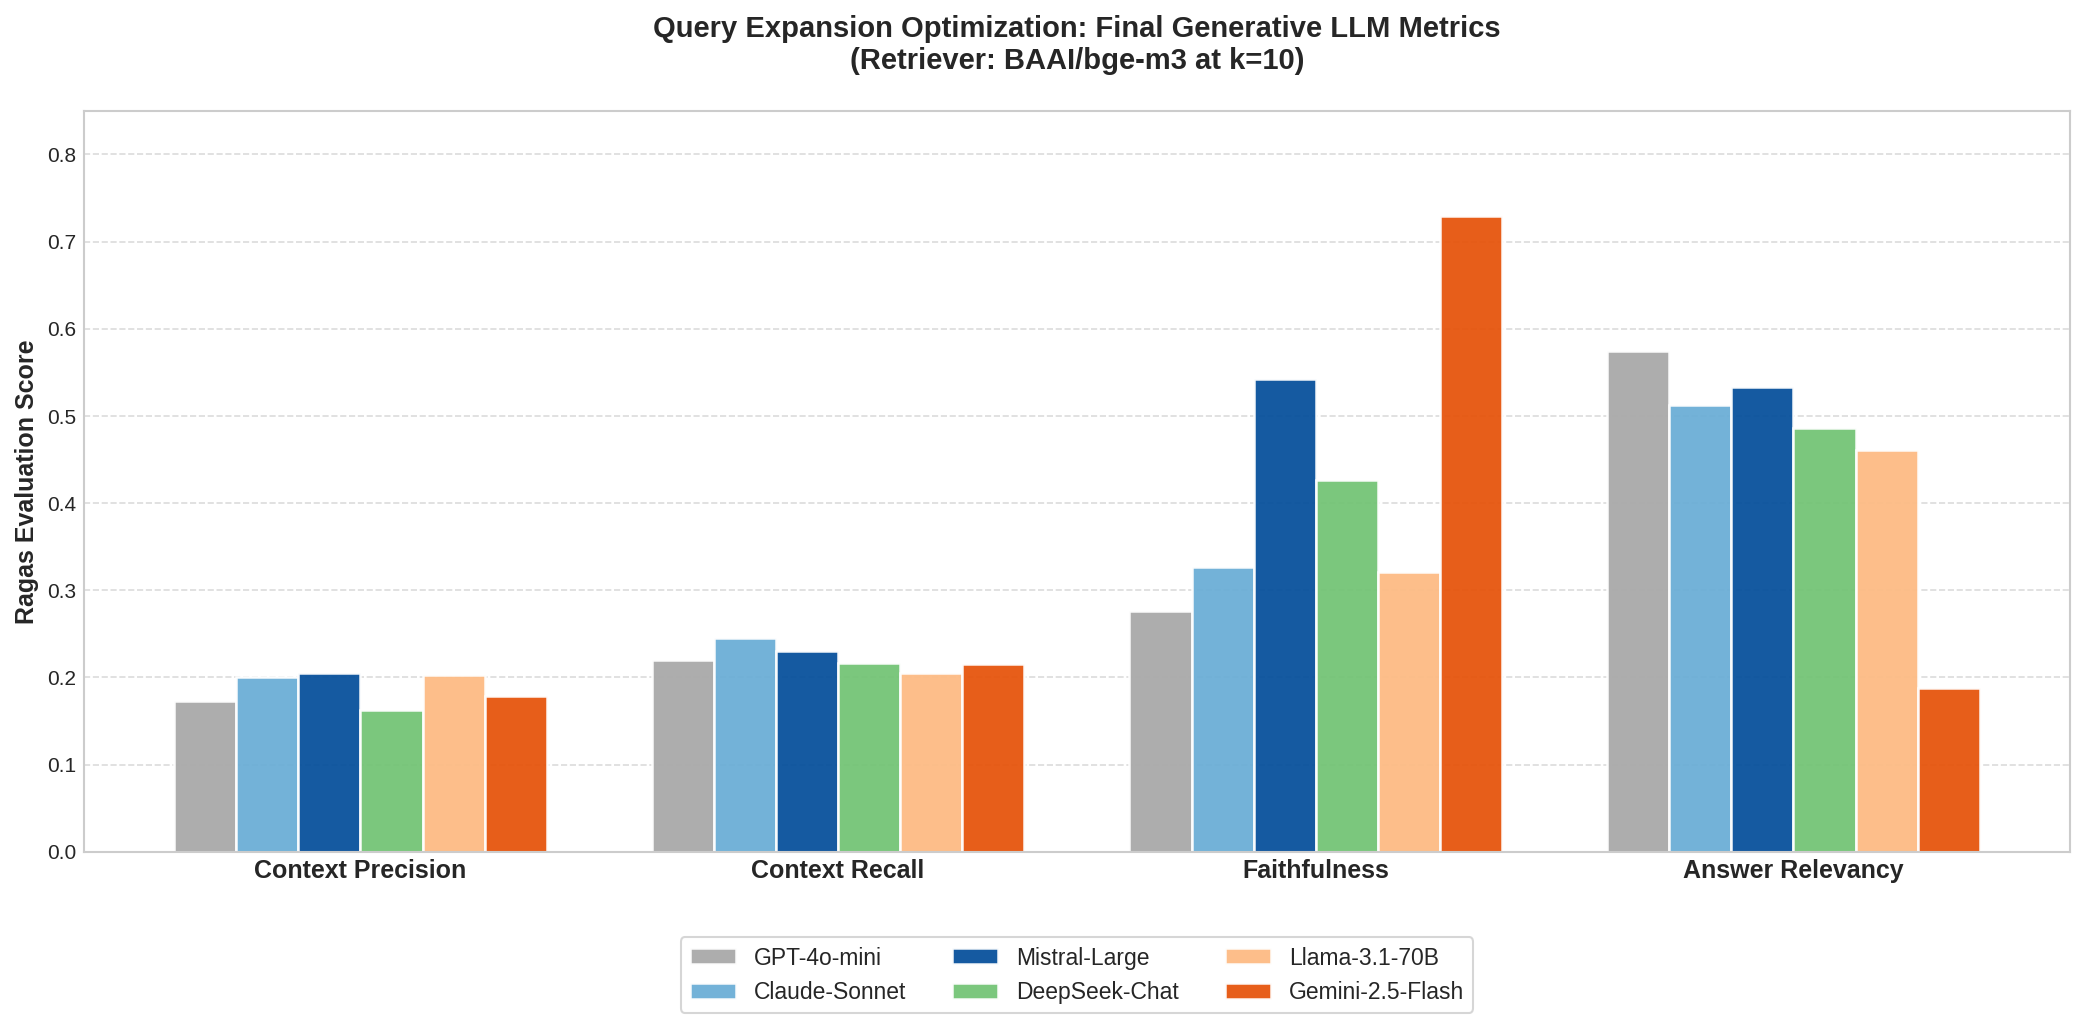

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Data for Query Expansion Results
models = ['GPT-4o-mini', 'Claude-Sonnet', 'Mistral-Large', 'DeepSeek-Chat', 'Llama-3.1-70B', 'Gemini-2.5-Flash']
metrics = ['Context Precision', 'Context Recall', 'Faithfulness', 'Answer Relevancy']

# Scores matrix: [Precision, Recall, Faithfulness, Relevancy] for each model
scores = {
    'GPT-4o-mini': [0.173, 0.220, 0.276, 0.575],
    'Claude-Sonnet': [0.200, 0.245, 0.327, 0.513],
    'Mistral-Large': [0.205, 0.230, 0.542, 0.533],
    'DeepSeek-Chat': [0.163, 0.217, 0.426, 0.486],
    'Llama-3.1-70B': [0.203, 0.205, 0.321, 0.461],
    'Gemini-2.5-Flash': [0.179, 0.215, 0.729, 0.188]
}

# 2. Plot Setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

x = np.arange(len(metrics))
width = 0.13
multiplier = 0

# 3. Academic Color Palette (Same as previous to ensure visual consistency)
colors = [
    '#A9A9A9', # Neutral Grey: GPT-4o-mini
    '#6BAED6', # Soft Blue: Claude-Sonnet
    '#08519C', # Deep Bold Blue: Mistral-Large (Winner)
    '#74C476', # Muted Green: DeepSeek-Chat
    '#FDBB84', # Soft Peach: Llama-3.1-70B
    '#E6550D'  # Deep Rust/Red: Gemini-2.5-Flash
]

# 4. Draw the Bars
for (model, color) in zip(models, colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores[model], width, label=model, color=color, edgecolor='white', linewidth=1.2, alpha=0.95)
    multiplier += 1

# 5. Formatting and Labels
ax.set_ylabel('Ragas Evaluation Score', fontsize=12, fontweight='bold')
ax.set_title('Query Expansion Optimization: Final Generative LLM Metrics\n(Retriever: BAAI/bge-m3 at k=10)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.85)

# Add Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11, frameon=True)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()

# 6. Save image
plt.savefig('/content/drive/MyDrive/expansion_battle_chart.png', bbox_inches='tight')
plt.show()